# 02 · Feature Engineering + Engineered-Data EDA

**When to run this notebook:** whenever you change the feature set (new feature
combinations) or refresh the data pull. It runs the pipeline through feature
engineering on the latest committed snapshot, optionally persists the engineered
splits, and analyzes the **post-engineering** data.

## Why feature engineering matters here

Raw counts are right-skewed and channel-size-dependent (notebook 01). The feature
engineering stage converts them into scale-invariant, channel-relative signals
that are far more predictive and more linearly separable: engagement
velocity/acceleration, baseline-comparison ratios, normalized engagement rates,
subscriber-normalized metrics, content/metadata features, and segment encodings.

> **Sequence:** notebook 2 of 5. See [notebooks.md](./notebooks.md).

## Configuration & flags

- **`IS_DRY_RUN`** (default `True`) — the single write guardrail. When `True`,
  nothing is persisted: no engineered splits to GCS and no figures to disk, and
  the build summary reports every version as unchanged. Flip to `False` **only
  when the feature-engineering code changed** and you want to persist the new
  engineered splits (which bumps the data version) and save figures.
- **`.skip_eda()`** — chain this builder method onto the config to skip the
  (slower) post-engineering EDA plots when you only need to rebuild or snapshot
  the engineered data. Omit it (the default) to run the EDA. Read back via
  `config.is_skip_eda`.

In [1]:
import sys
import os

# Make the capstone package importable (notebook lives in notebooks/, code in src/capstone/).
sys.path.append(os.path.abspath("../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline.version_config import VersionConfig
from pipeline.pipeline_run import PipelineRun
from pipeline.factory import PipelineFactory
from pipeline.stages import eda

IMAGES_FOLDER = "../../../images/eda/"

# Write new figure PNGs, but persist NO data. SAVE_FIGURES controls image output;
# PERSIST_DATA stays False so the engineered splits are NOT written to GCS and no
# data version is bumped (dry_run(True) governs every data write here).
SAVE_FIGURES = True
PERSIST_DATA = False

def fig_path(name):
    return f"{IMAGES_FOLDER}{name}" if SAVE_FIGURES else None

config = (
    VersionConfig.load(use_synthetic=False)
    .snapshot_final()
    .dry_run(not PERSIST_DATA)
    .build()
)

run = PipelineRun(config)
stages = PipelineFactory.retrain_existing_data(config)

VersionConfig loaded:
  data:          v3.5 (raw_suffix='real')
  baselines:     v5.0
  model:         v6.2
  hyperparams:   v1.2
  use_synthetic: False

VersionConfig ready:
  Active flags      : ['none (dry run)']
  data              : v3.5 (unchanged)
  baselines         : v5.0 (unchanged)
  model             : v6.2 (unchanged)
  hyperparams       : v1.2 (unchanged)
  raw_version       : v3.5_real
  next_final_version: v3.5_100real
  model_version     : v6.2
  baselines_version : v5.0
  hyperparam_version: v1.2
  use_synthetic     : False
  dry_run           : True  (no GCS writes will occur)

  DRY RUN — set .dry_run(False) to persist artifacts and commit versions.


### Pipeline execution — through feature engineering, split & scale

`DataLoader` → `DataPreprocessor` → `FeatureEngineer` → `DataSplitter` →
`Scaler`. The feature-engineering *logic* lives in
`data_processing/feature_engineering.py`; this notebook simply runs it so the
effect of any change is reflected in `run.df_engineered` and the splits.

In [2]:
stages.loader.run(run)
stages.preprocessor.run(run)
stages.engineer.run(run)
stages.splitter.run(run)
stages.scaler.run(run)
run.summary()

Loaded snapshot 'v3.5_real': 106626 rows from 2026-05-29
  Polls: {'upload': 37387, '24h': 36506, '7d': 32733}


Loaded baselines 'v5.0': 40841 baseline videos, 1375 median rows (1375 channels)
Building clean dataset
snapshot cols: Index(['video_id', 'poll_timestamp', 'channel_id', 'channel_handle', 'title',
       'view_count', 'like_count', 'comment_count', 'face_count', 'brightness',
       'colorfulness', 'vertical', 'tier', 'description', 'tags',
       'duration_seconds', 'category_id', 'category_name', 'published_at',
       'poll_label', 'hours_since_publish', 'subscriber_count',
       'contains_synthetic_media'],
      dtype='object')

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 32571 (dropped 4864 incomplete)
  Pivoted shape: (32740, 34)

[2/3] Joining baseline medians...
  Baseline join: 32740/32740 videos matched a channel median

[3/3] Cleaning data...
  Dropped 15 row(s) with null contains_synthetic_media (private/failed harvest).
  Cleaned: 32725 rows × 40 columns

Clean dataset: 32725 rows × 40 columns
  all: dropped 599 rows with NaN in a baseline_median_* column or 0

Engineering features

[1/10] Computing target variable...
  Target distribution: 54.9% above baseline, 45.1% below

[2/10] Computing velocity features...
  Computed velocity, upload momentum, normalized velocity, and acceleration features

[3/10] Computing ratio and baseline-normalized features...
  Computed ratio and baseline-normalized features

[4/10] Computing subscriber-normalized metrics...
  Computed subscriber-normalized metrics for upload/24h/7d

[5/10] Computing categorical features...


  Title categories:
title_category
neutral        20050
all_caps        3752
exclamation     3455
question        2932
listicle        1054
how_to           408
clickbait        356
emoji_heavy      119
  Description categories:
desc_category
link_heavy        8772
minimal           7616
has_links         6764
has_hashtags      4788
neutral           2681
has_timestamps    1439
long_form           66

[6/10] Computing text structural features...
  Computed text structural features

[7/10] Computing temporal features...
  Computed temporal features

[8/10] Computing duration features...
  Computed duration features

[9/10] Computing thumbnail features...
  Computed thumbnail features

[10/10] Computing interaction features...
  Computed is_short interaction features

Modeling table: 32126 rows × 85 columns
Target balance: {1: 17628, 0: 14498}


DataSplitter — loaded holdout (5,192 val rows):
  df_val:    5,192 rows (17.5%)
  df_train: 19,589 rows (66.0%)
  df_test:   4,898 rows (16.5%)
DataSplitter — gen split: 2,447 rows (Music/Sports, grows over time)
  Music_L: 78
  Music_M: 255
  Music_S: 236
  Sports_L: 484
  Sports_M: 574
  Sports_S: 820
PipelineRun(config=VersionConfig(data=(3, 5), model=(6, 2), baselines=(5, 0), hyperparams=(1, 2), use_synthetic=False, active=['final']))
  df_videos      populated  DataFrame shape=(106626, 23)
  df_baselines   populated  DataFrame shape=(40841, 15)
  df_medians     populated  DataFrame shape=(1375, 7)
  df_clean       populated  DataFrame shape=(32725, 40)
  df_engineered  populated  DataFrame shape=(32126, 89)
  df_train       populated  DataFrame shape=(19589, 89)
  df_test        populated  DataFrame shape=(4898, 89)
  df_val         populated  DataFrame shape=(5192, 89)
  df_gen         populated  DataFrame shape=(2447, 89)
  X_train        populated  DataFrame shape=(19589, 55)
 

### (Optional) persist the engineered splits

With `IS_DRY_RUN=False`, `FinalSnapshotter` writes the six per-split artifacts
(`X_train/y_train/X_test/y_test/X_val/y_val`) to GCS at `config.next_final_version`.
In a dry run this prints a "skipped" message and writes nothing.

In [3]:
stages.final_snapshotter.run(run)

[dry_run] FinalSnapshotter — GCS write skipped.


PipelineRun(model_version='v6.2', num_synth_rows=0, populated=['df_videos', 'df_baselines', 'df_medians', 'df_clean', 'df_engineered', 'df_train', 'df_test', 'df_val', 'df_gen', 'X_train', 'X_test', 'X_val', 'X_val_unscaled', 'X_gen', 'y_train', 'y_test', 'y_val', 'y_gen'])

## Post-feature-engineering analysis

`df_engineered` is the modeling-ready table: the `above_baseline` target plus all
derived features. The analysis below is gated by `config.is_skip_eda` (set via
`.skip_eda()`).

In [4]:
if config.is_skip_eda:
    print("skip_eda — skipping the engineered-vs-clean shape comparison.")
else:
    clean_cols_ = set(run.df_clean.columns)
    eng_cols_ = set(run.df_engineered.columns)
    new_cols_ = sorted(eng_cols_ - clean_cols_)
    dropped_cols_ = sorted(clean_cols_ - eng_cols_)

    print(f"df_clean shape:      {run.df_clean.shape[0]:,} rows x {run.df_clean.shape[1]} columns")
    print(f"df_engineered shape: {run.df_engineered.shape[0]:,} rows x {run.df_engineered.shape[1]} columns")
    print(f"\nNew columns added ({len(new_cols_)}):")
    for c in new_cols_:
        print(f"  {c}")
    if dropped_cols_:
        print(f"\nColumns dropped ({len(dropped_cols_)}):")
        for c in dropped_cols_:
            print(f"  {c}")

df_clean shape:      32,725 rows x 40 columns
df_engineered shape: 32,126 rows x 89 columns

New columns added (49):
  above_baseline
  baseline_engagement
  comment_count_velocity_24h
  comments_per_sub_24h
  comments_per_sub_7d
  comments_per_sub_upload
  desc_category
  desc_hashtag_count
  desc_length
  desc_link_count
  duration_bucket
  engagement_7d
  has_face
  has_tags
  is_long
  is_short
  is_short_x_like_rate_24h
  is_short_x_view_velocity_ratio
  like_count_upload_vs_baseline
  like_count_velocity_24h
  like_rate_24h
  like_rate_upload
  like_velocity_acceleration
  like_velocity_per_sub_24h
  like_velocity_upload
  likes_per_sub_24h
  likes_per_sub_7d
  likes_per_sub_upload
  publish_dayofweek
  publish_hour
  publish_is_weekend
  subscriber_count_velocity_24h
  tag_count
  tier_encoded
  title_category
  title_length
  title_word_count
  vertical_Education
  vertical_Lifestyle
  vertical_Tech
  view_count_upload_vs_baseline
  view_count_velocity_24h
  view_velocity_accel

### Engineered feature distributions

Compared to the raw `df_clean` histograms in notebook 01, the ratio/rate features
here are visibly more symmetric — dividing two power-law quantities yields a
distribution closer to log-normal, which is what makes them more useful to the
linear model.

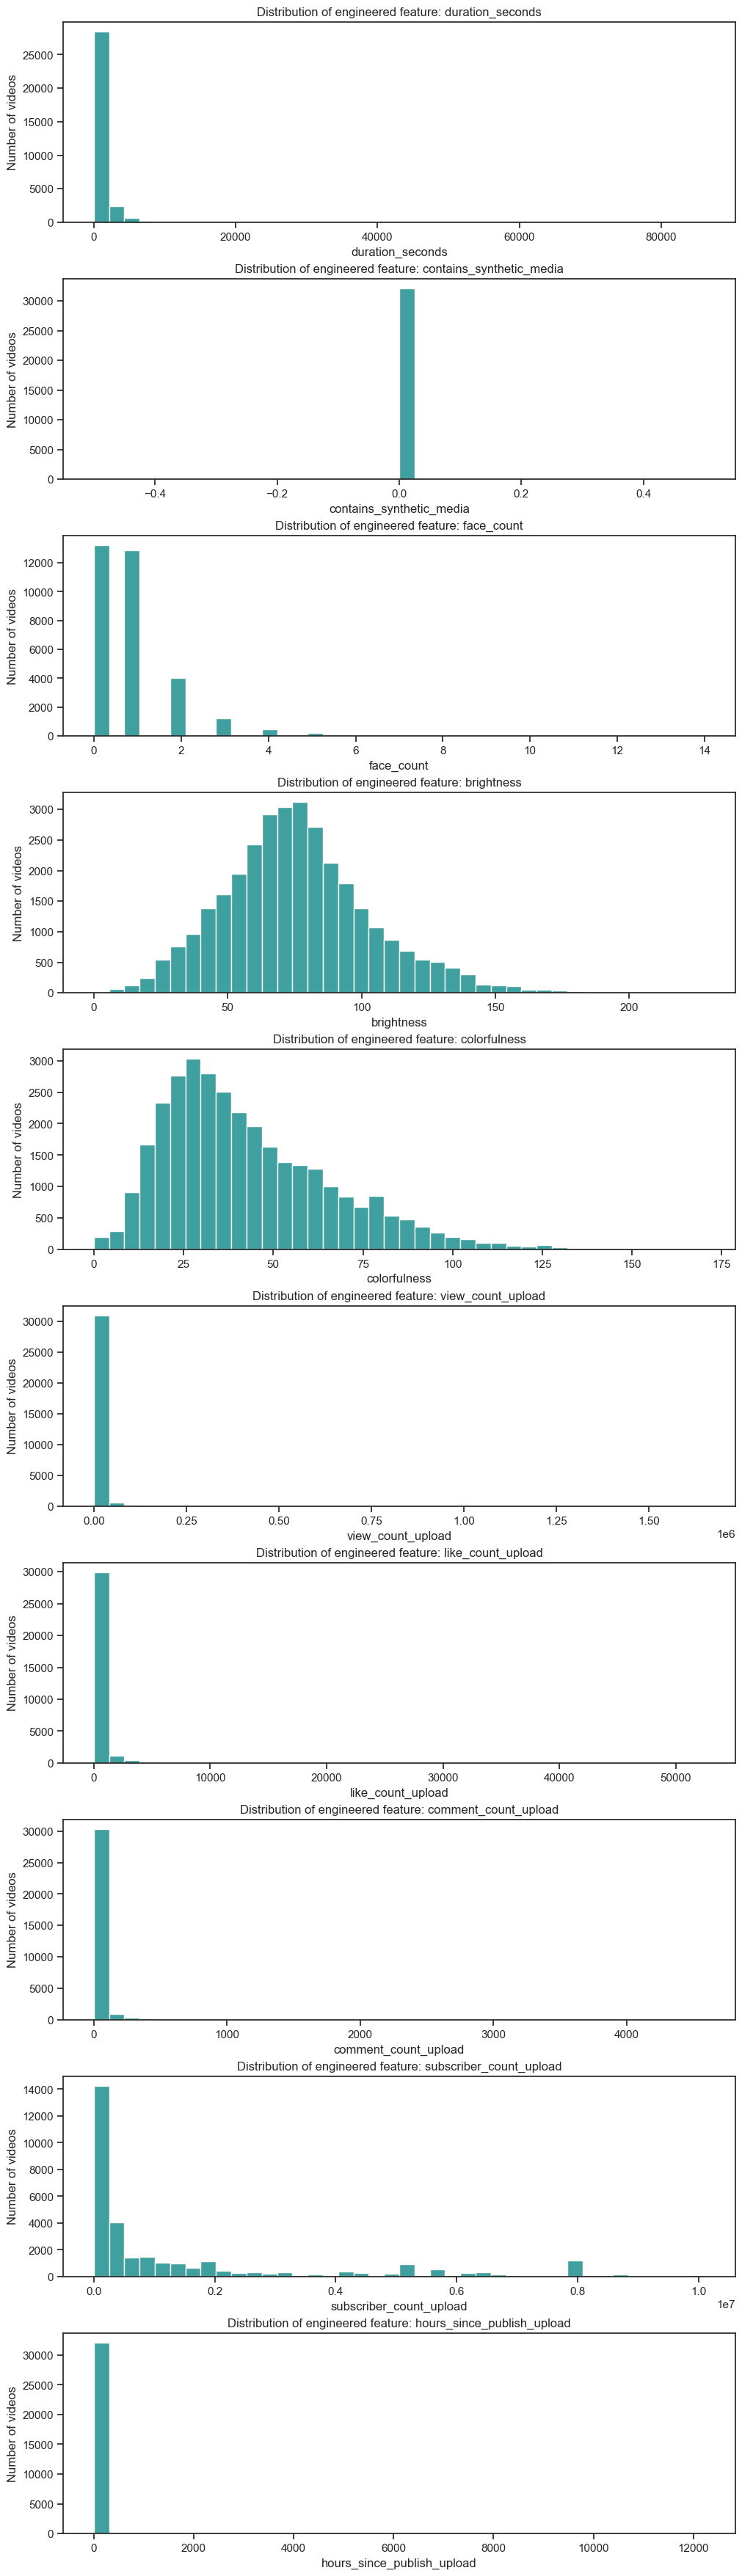

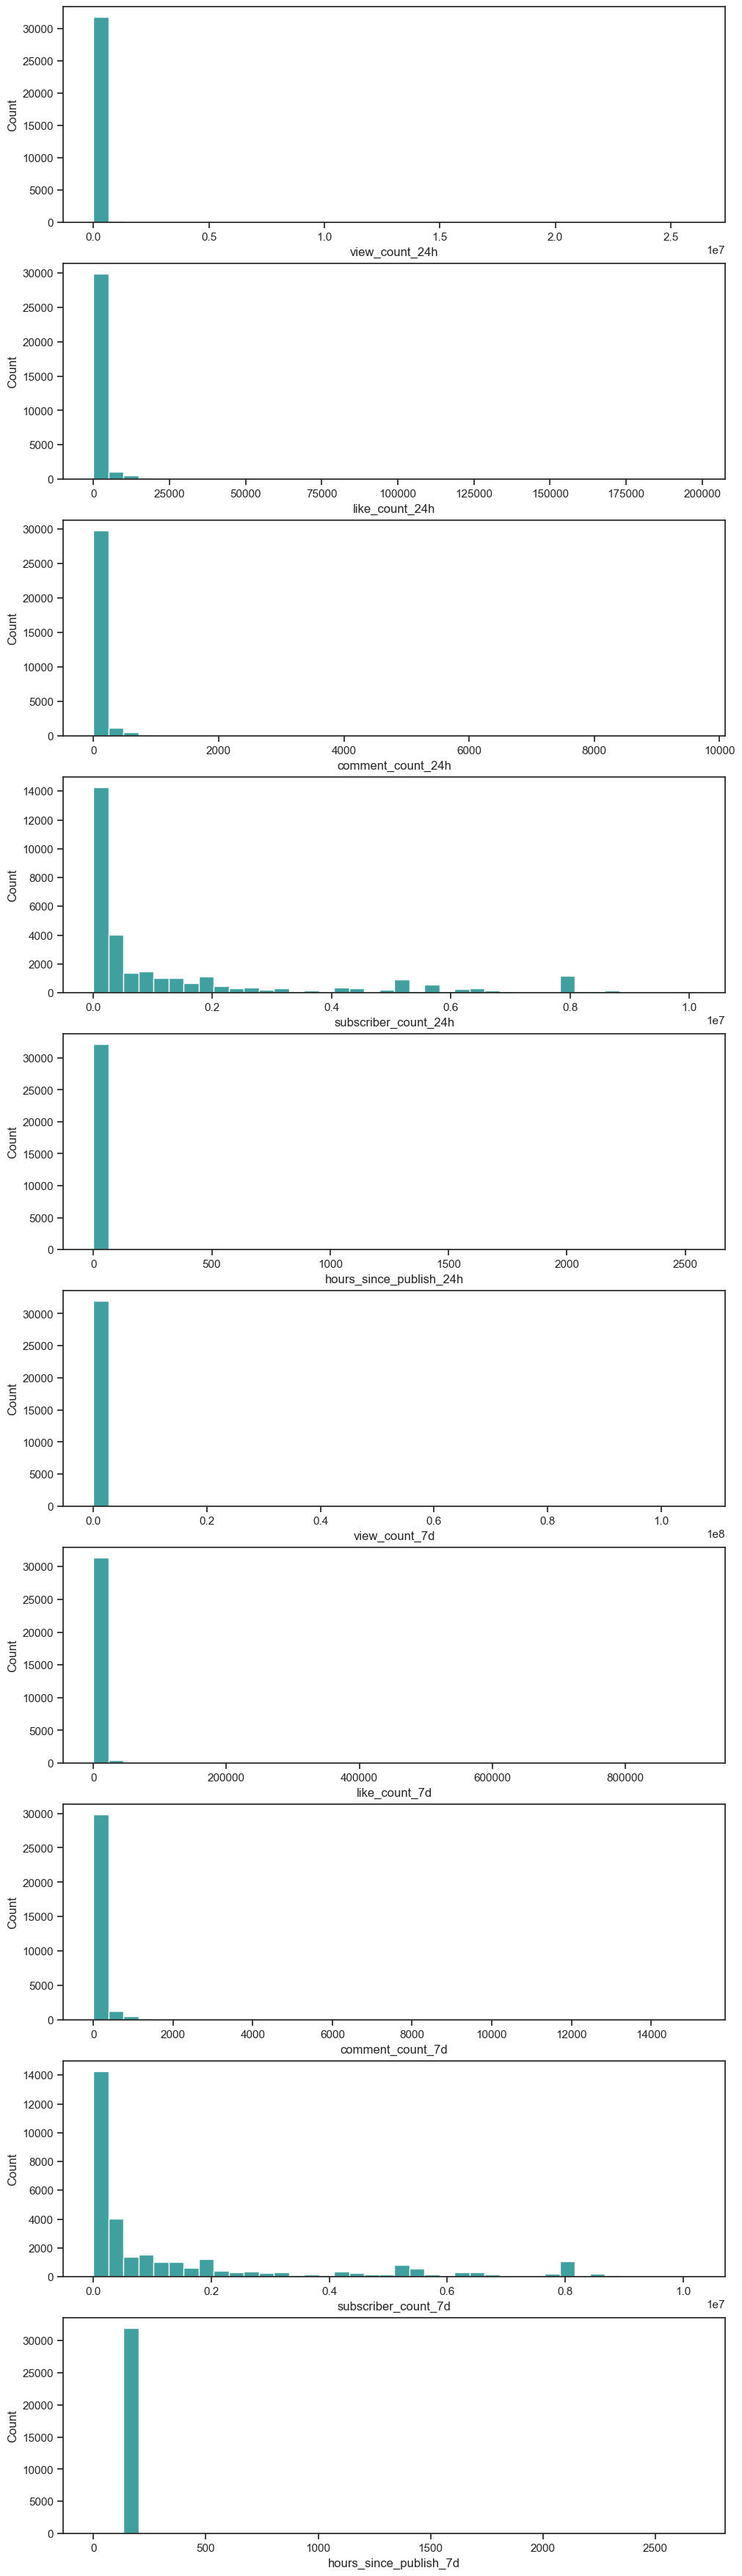

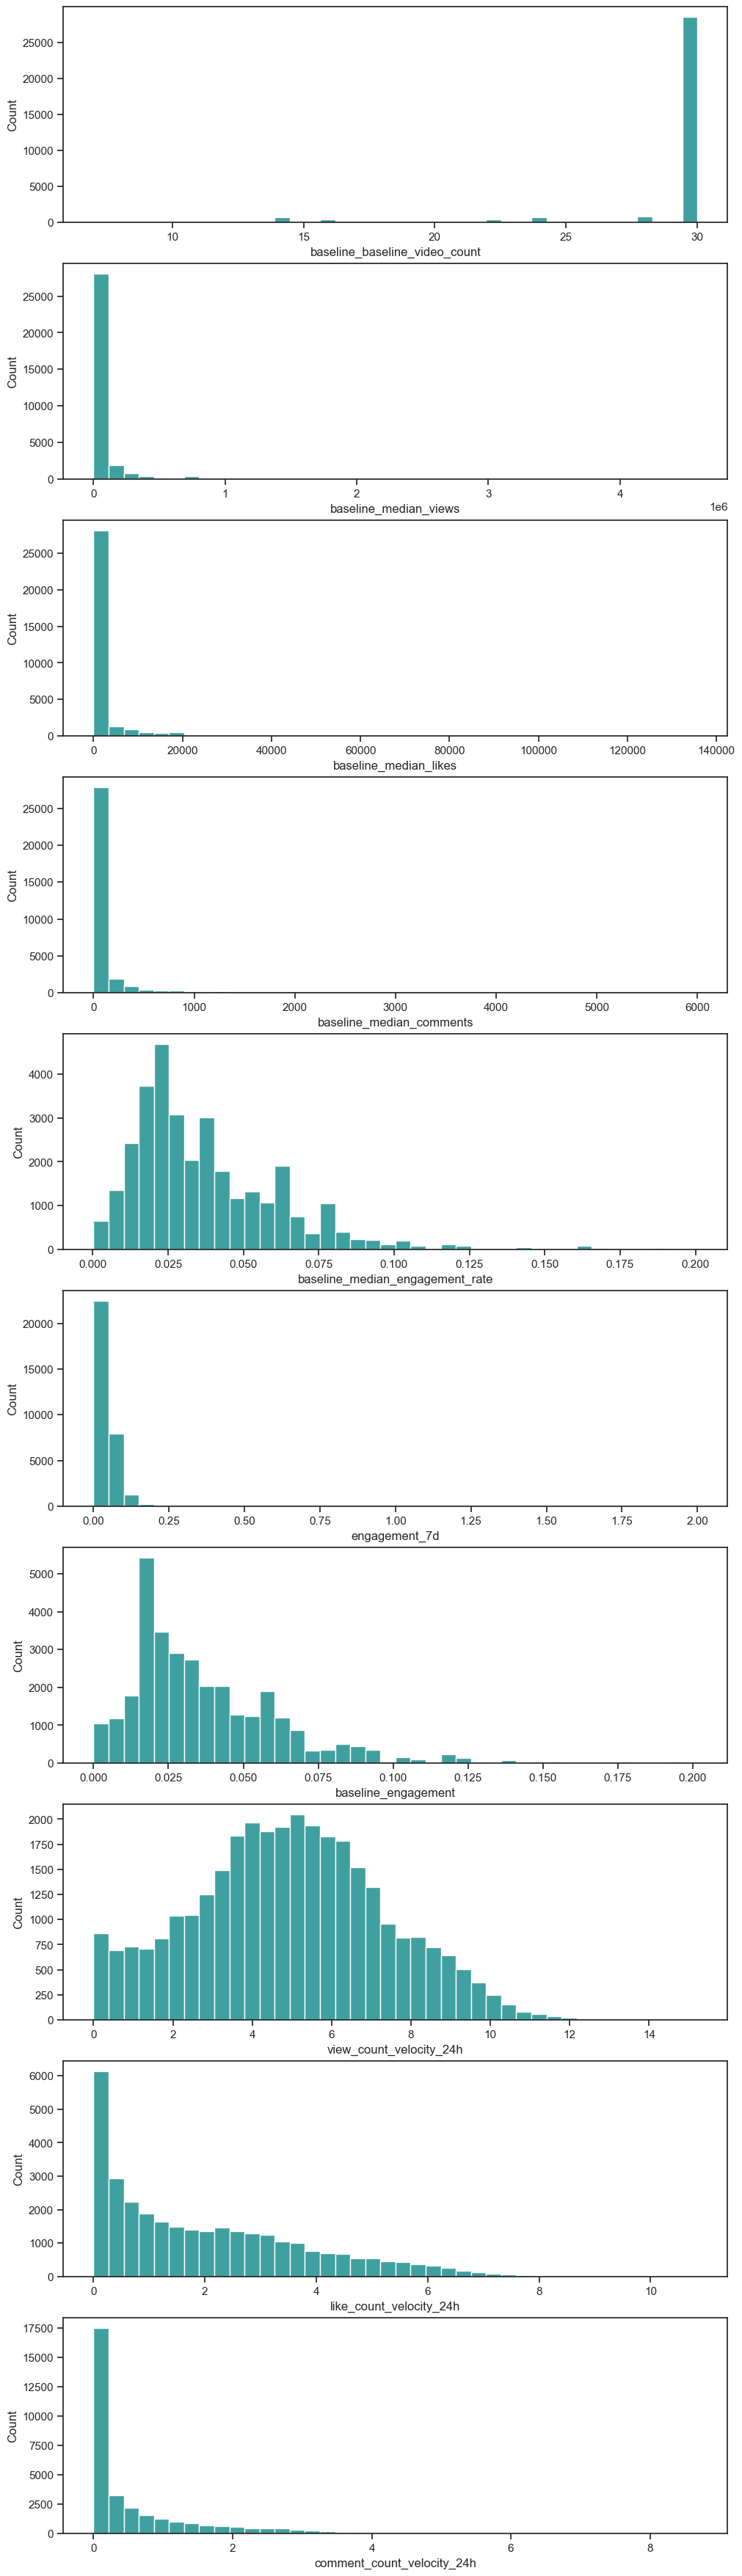

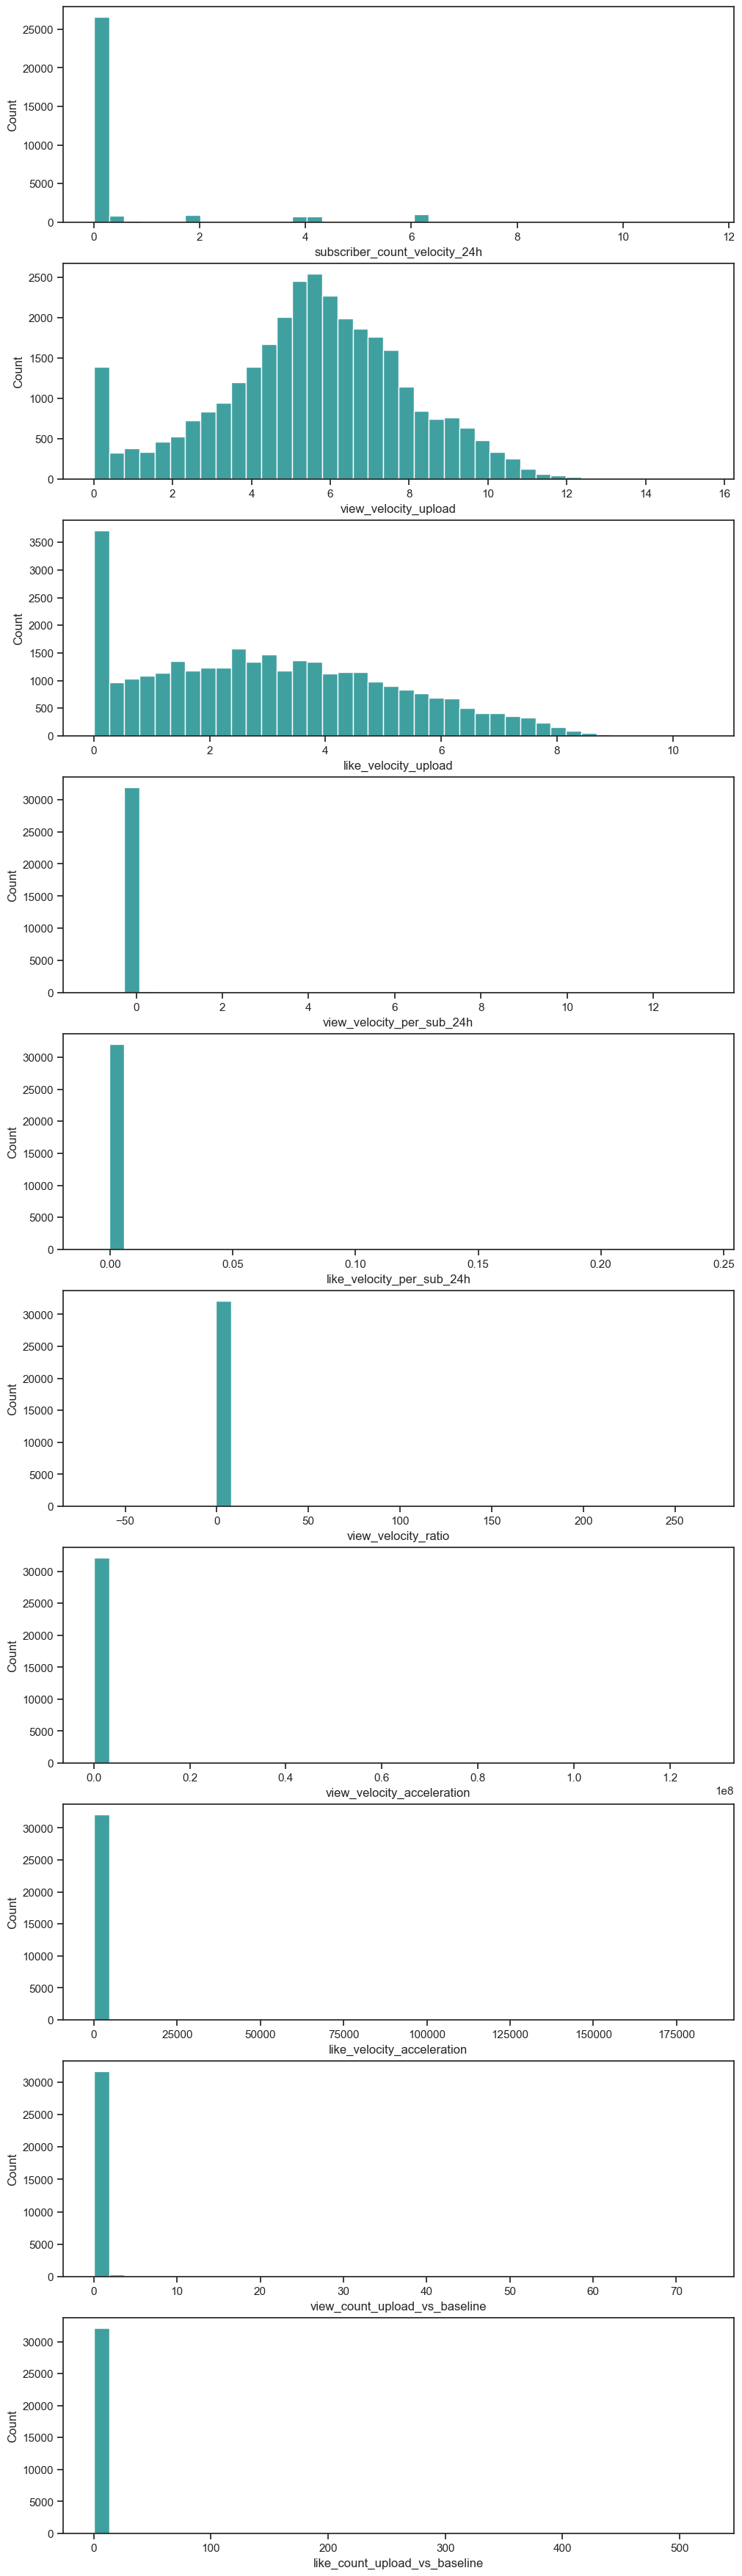

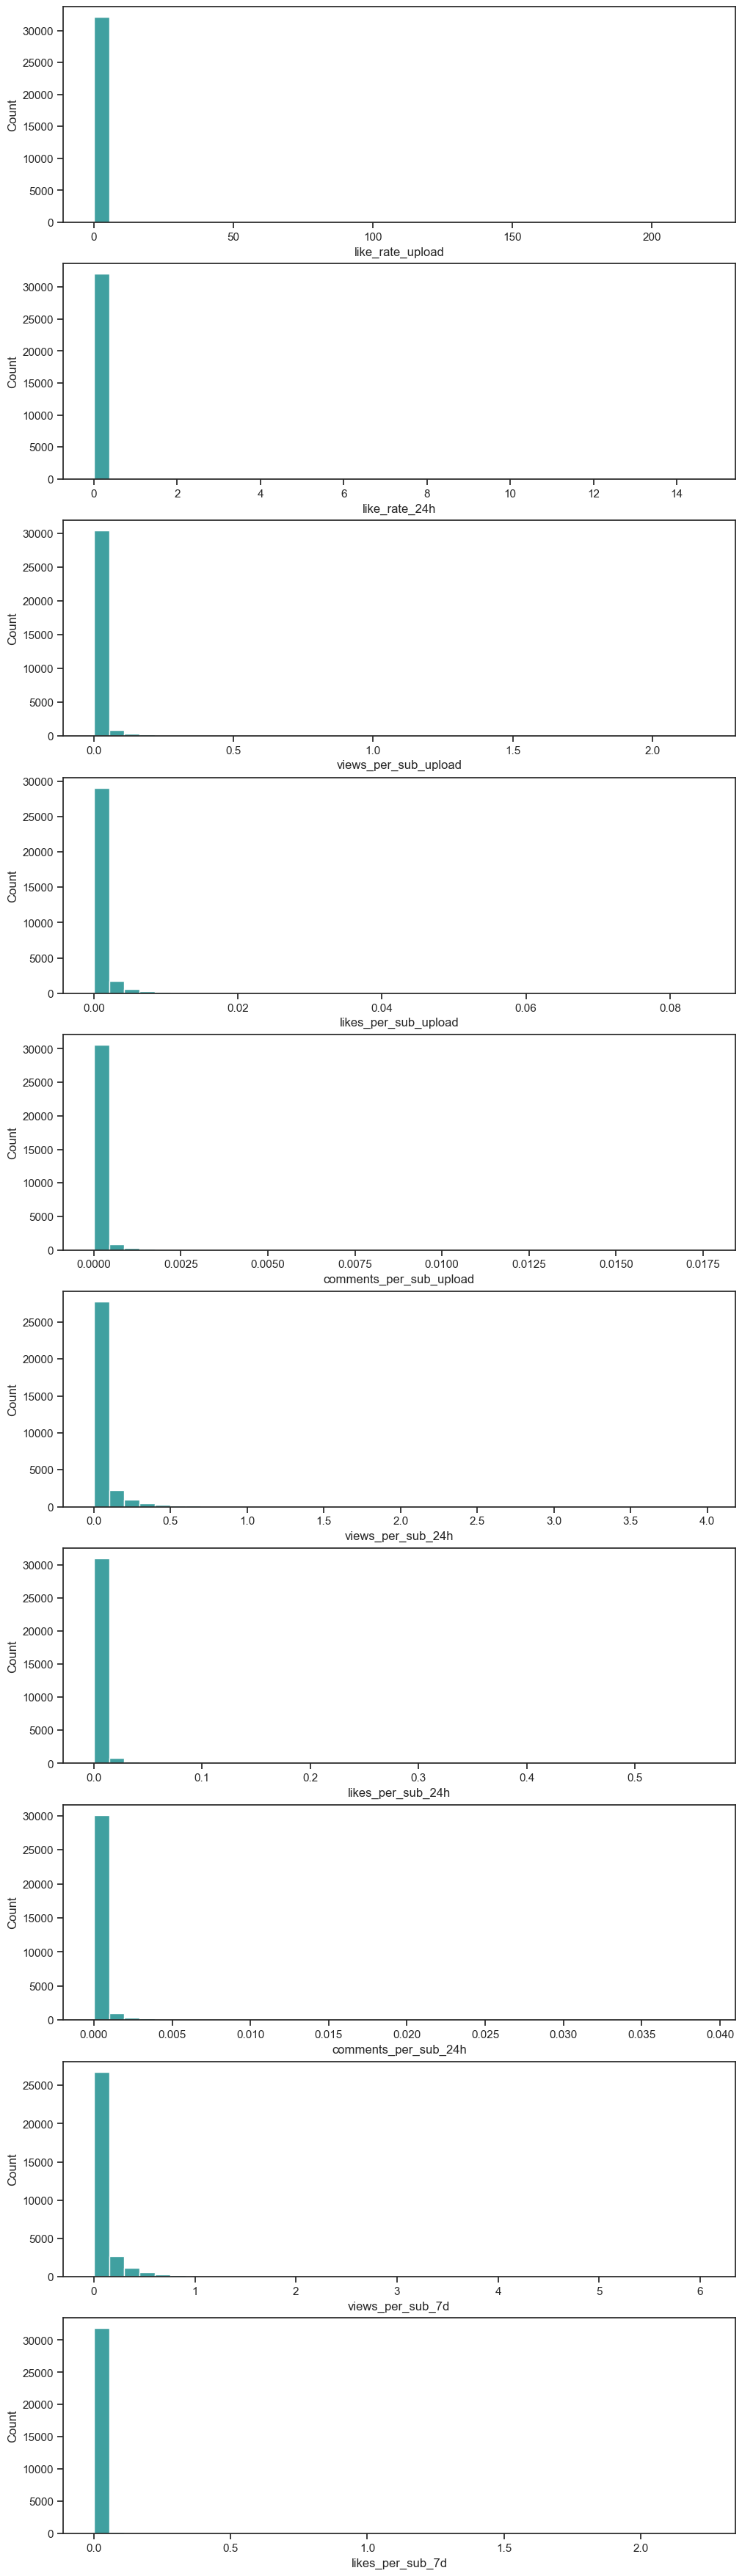

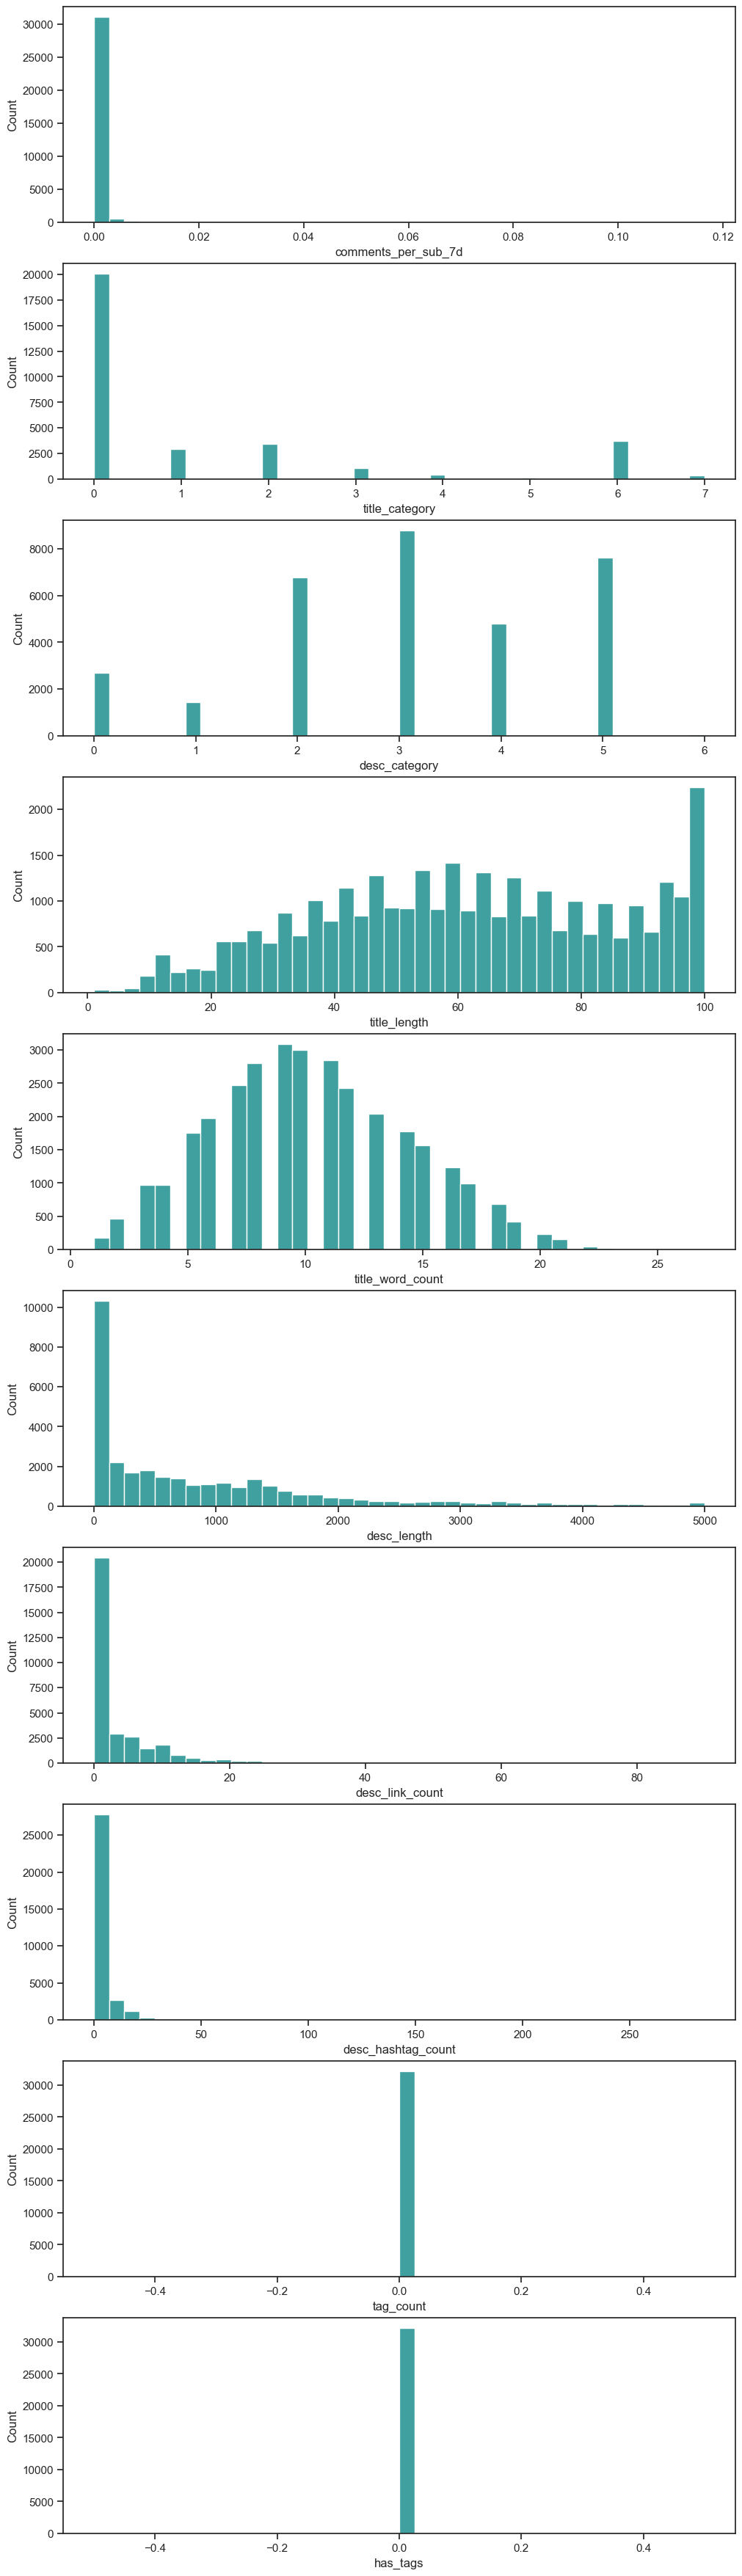

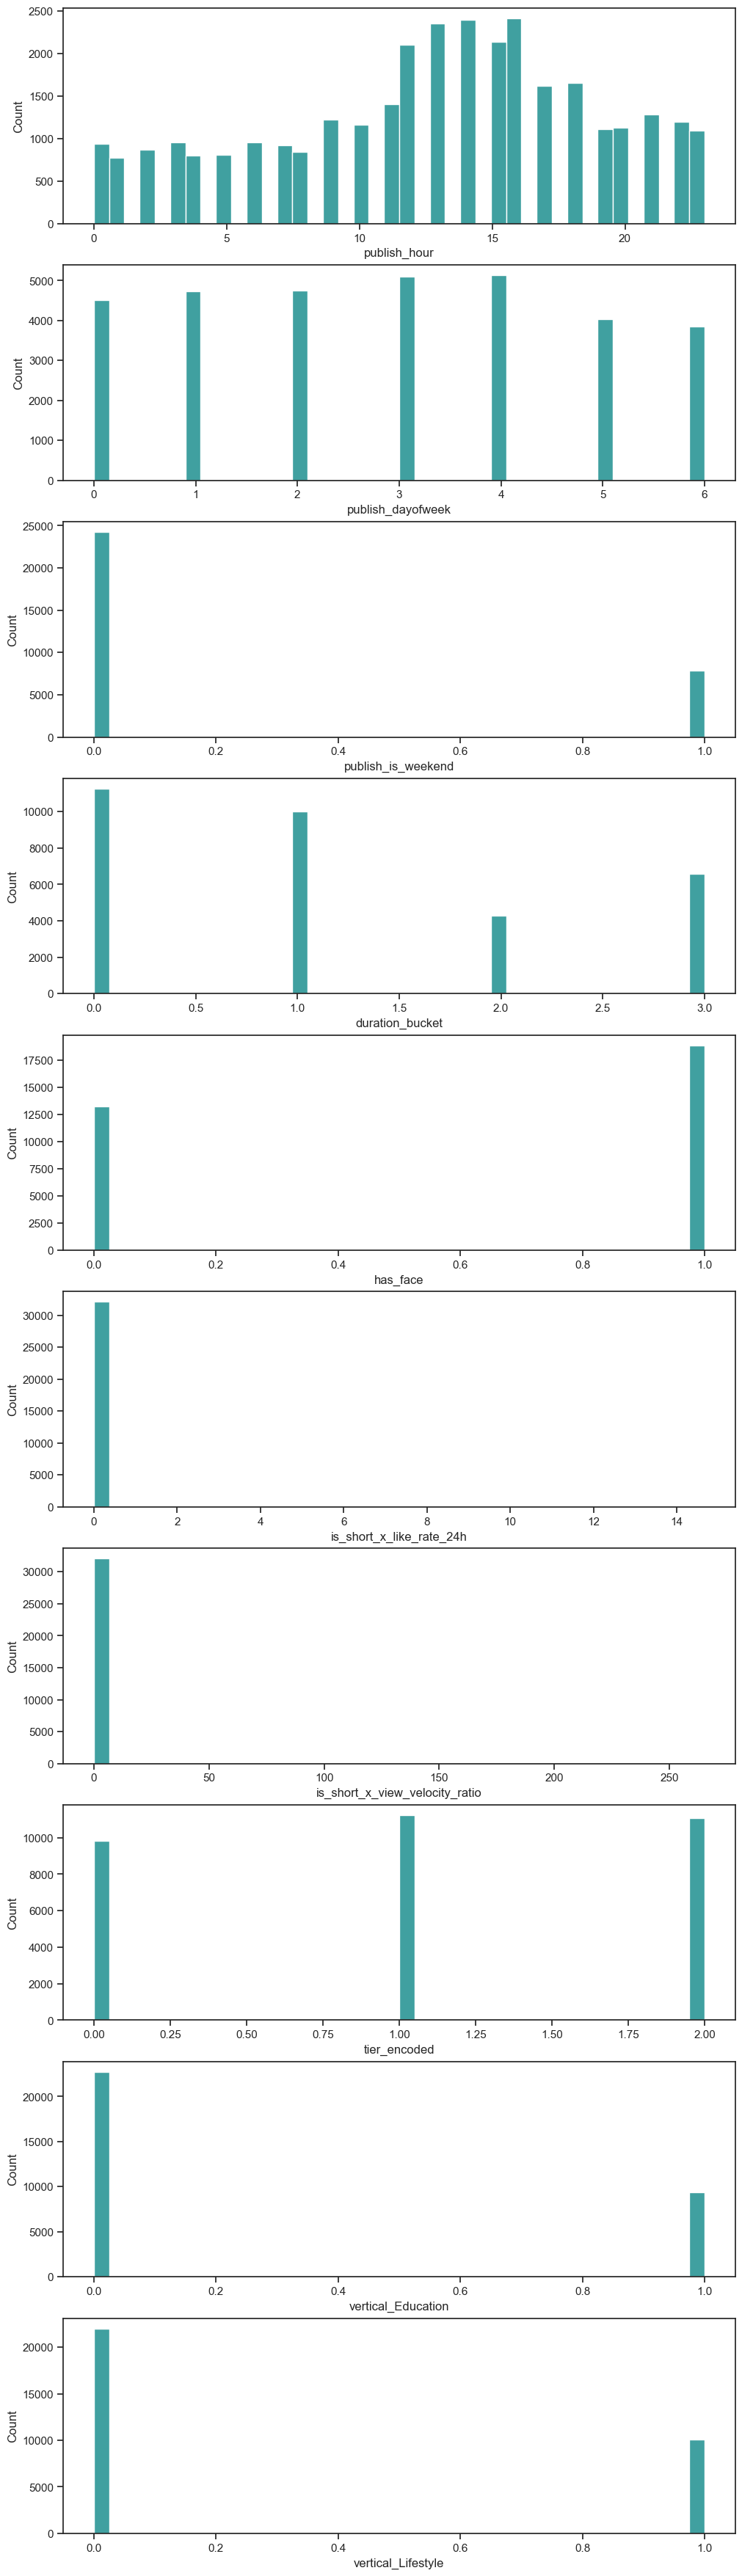

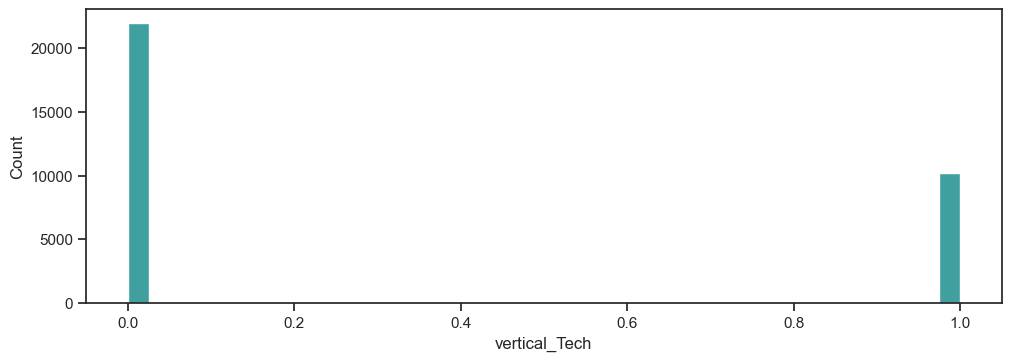

In [5]:
if config.is_skip_eda:
    print("skip_eda — skipping engineered feature distributions.")
else:
    eda.set_active_df(run, run.df_engineered)
    for page, (fig, axes, cols) in enumerate(eda.plot_engagement_distribution(run), start=1):
        for ax, col in zip(axes, cols):
            ax.set_title(f"Distribution of engineered feature: {col}")
            ax.set_xlabel(col)
            ax.set_ylabel("Number of videos")
        eda.save_fig(fig, fig_path("04_engineered_feature_distribution.png"), page=page)
        plt.show()

### Target class balance by vertical & tier

Because the target is channel-relative, the global rate is ~50% by construction.
Deviations within a vertical/tier cell reveal structural effects, and are exactly
why the train/test/validation split is stratified on the 18-cell
`vertical × tier × above_baseline` key.

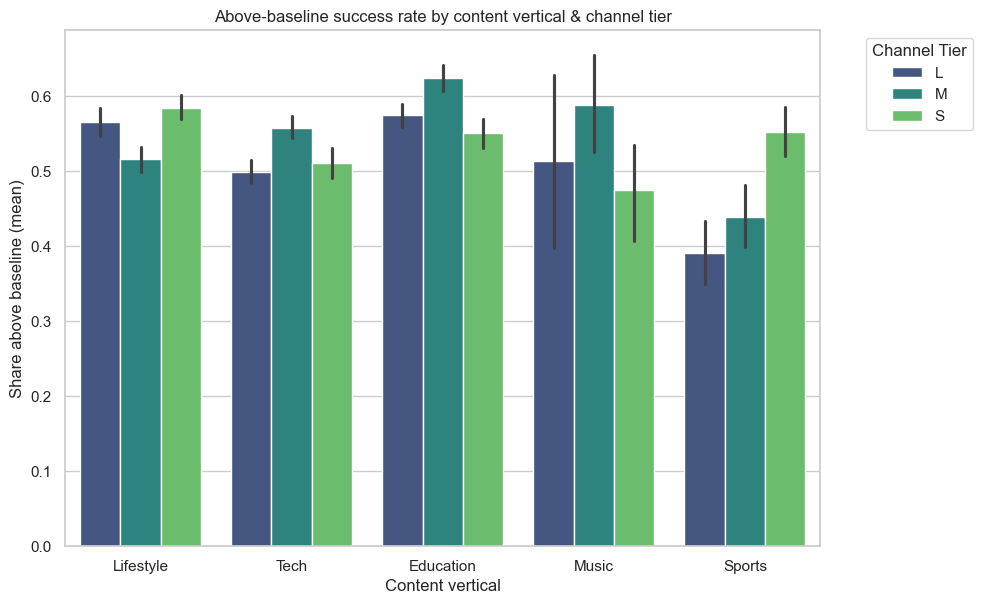

In [6]:
if config.is_skip_eda:
    print("skip_eda — skipping target class balance.")
else:
    eda.set_active_df(run, run.df_engineered)
    ax = eda.plot_label_rates(run)
    ax.set_title("Above-baseline success rate by content vertical & channel tier")
    ax.set_xlabel("Content vertical")
    ax.set_ylabel("Share above baseline (mean)")
    eda.save_fig(ax.figure, fig_path("05_target_class_balance_vertical_tier.png"))
    plt.show()

### Target correlation & leakage check

Pearson correlation of every feature against `above_baseline`, sorted by absolute
magnitude. The chart shows 57 features; six are 7d-derived (`views_per_sub_7d`,
`view_count_7d`, `comment_count_7d`, `like_count_7d`, `hours_since_publish_7d`,
`subscriber_count_7d`). They appear because `df_engineered` retains them for
diagnostic purposes, but they are **excluded from the model** before training — all
columns ending in `_7d` are dropped by `derive_feature_cols()` in
`pipeline/stages/feature_engineer.py`.

The 7d features do **not** have elevated |r| — one might expect them to, given that
the target is 7d-defined and they contain future information. The highest is
`views_per_sub_7d` at |r| ≈ 0.09 (rank 3); the remaining five are all below
|r| ≈ 0.05. Upon reflection, this is somewhat expected — the target (`above_baseline`)
is a relative metric that compares each video's 7d engagement rate to its channel's
historical median baseline, so raw and subscriber-normalized 7d counts are weak linear
predictors of that binary above/below comparison.

The dominant signals are content-format and early-signal features: `is_short`
(|r| ≈ 0.18), `duration_bucket` (|r| ≈ 0.14), and 24h-derived velocity and rate
features. These reflect what is knowable before the 7-day window closes, and are some of the key features the model actually uses.

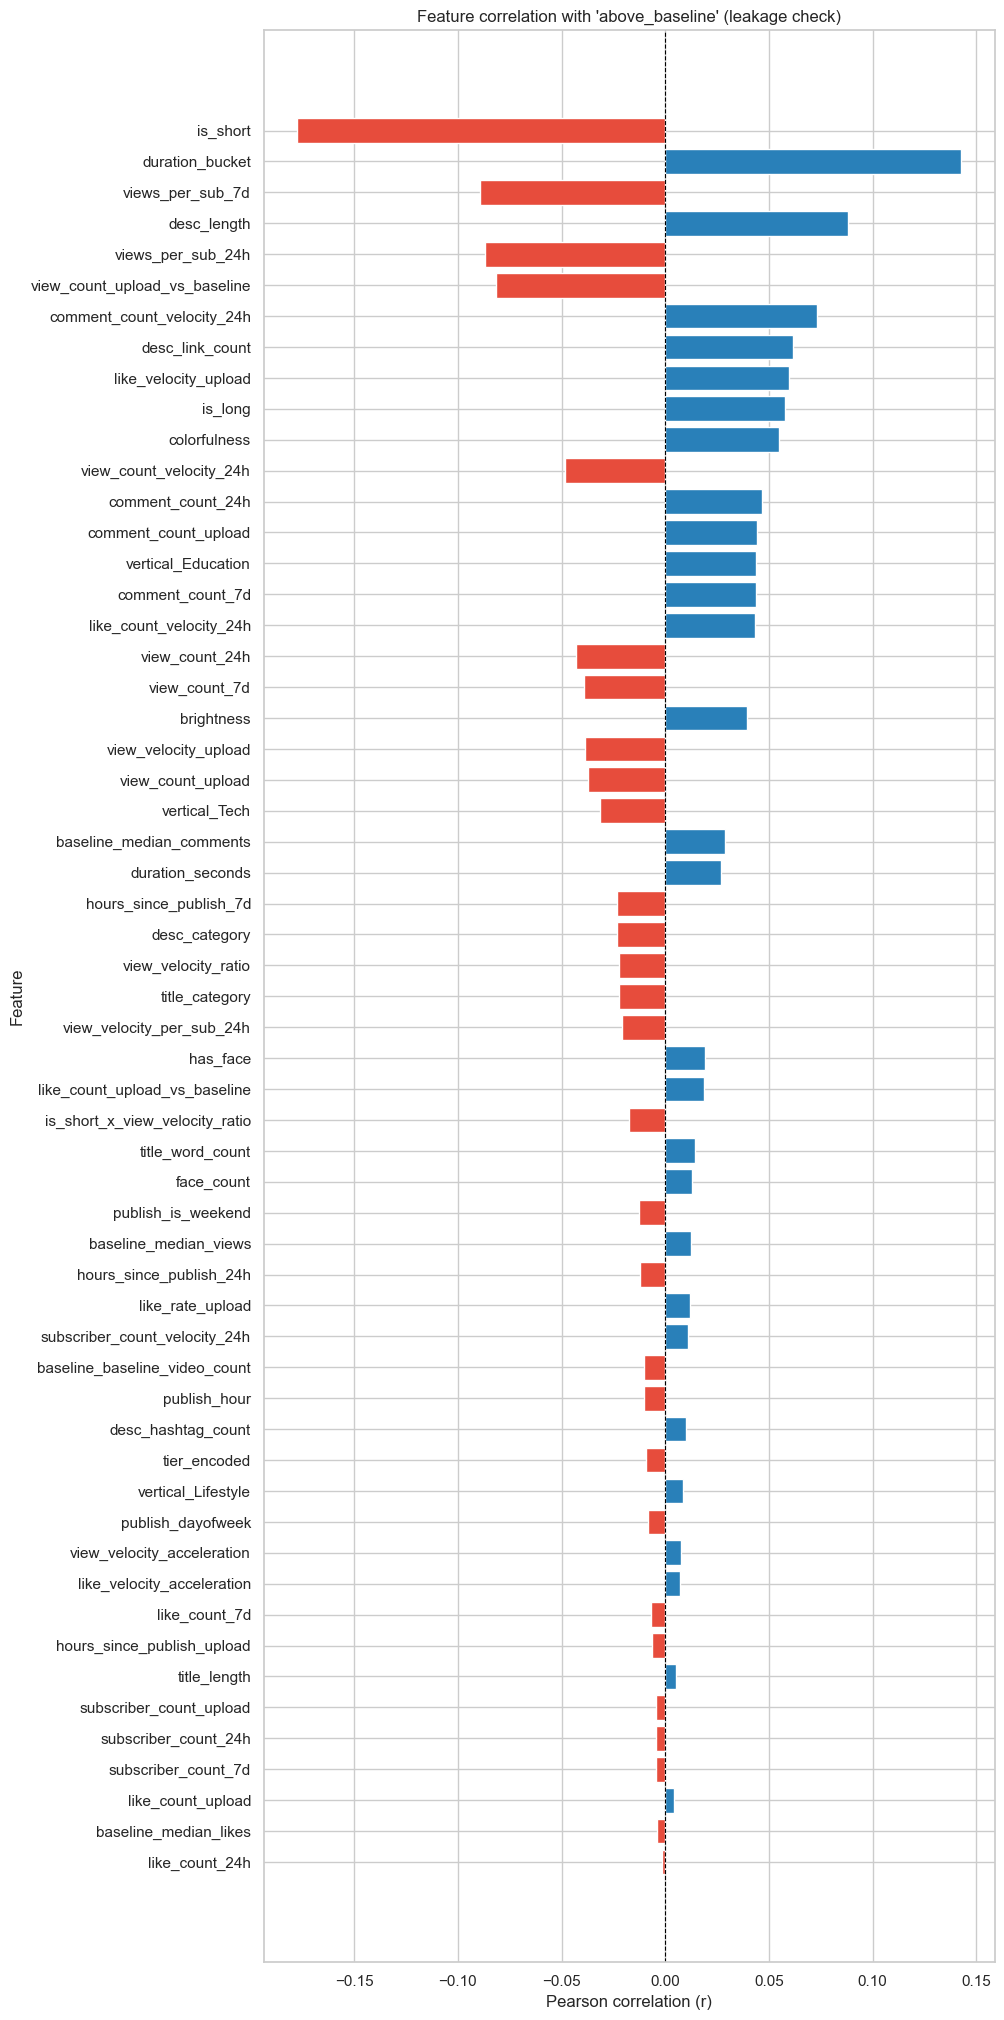

In [7]:
if config.is_skip_eda:
    print("skip_eda — skipping target correlation / leakage check.")
else:
    eda.set_active_df(run, run.df_engineered)
    ax = eda.plot_target_correlations(run)
    ax.set_title("Feature correlation with 'above_baseline' (leakage check)")
    ax.set_xlabel("Pearson correlation (r)")
    ax.set_ylabel("Feature")
    eda.save_fig(ax.figure, fig_path("06_target_correlation.png"))
    plt.show()

### Feature correlation heatmap

Lower-triangle correlation matrix across engineered features. Blocks of high |r|
flag near-collinear feature clusters (candidates for the L1/L2 regularization
already applied, or for removal). The `above_baseline` row should be consistent
with the focused bar chart above.

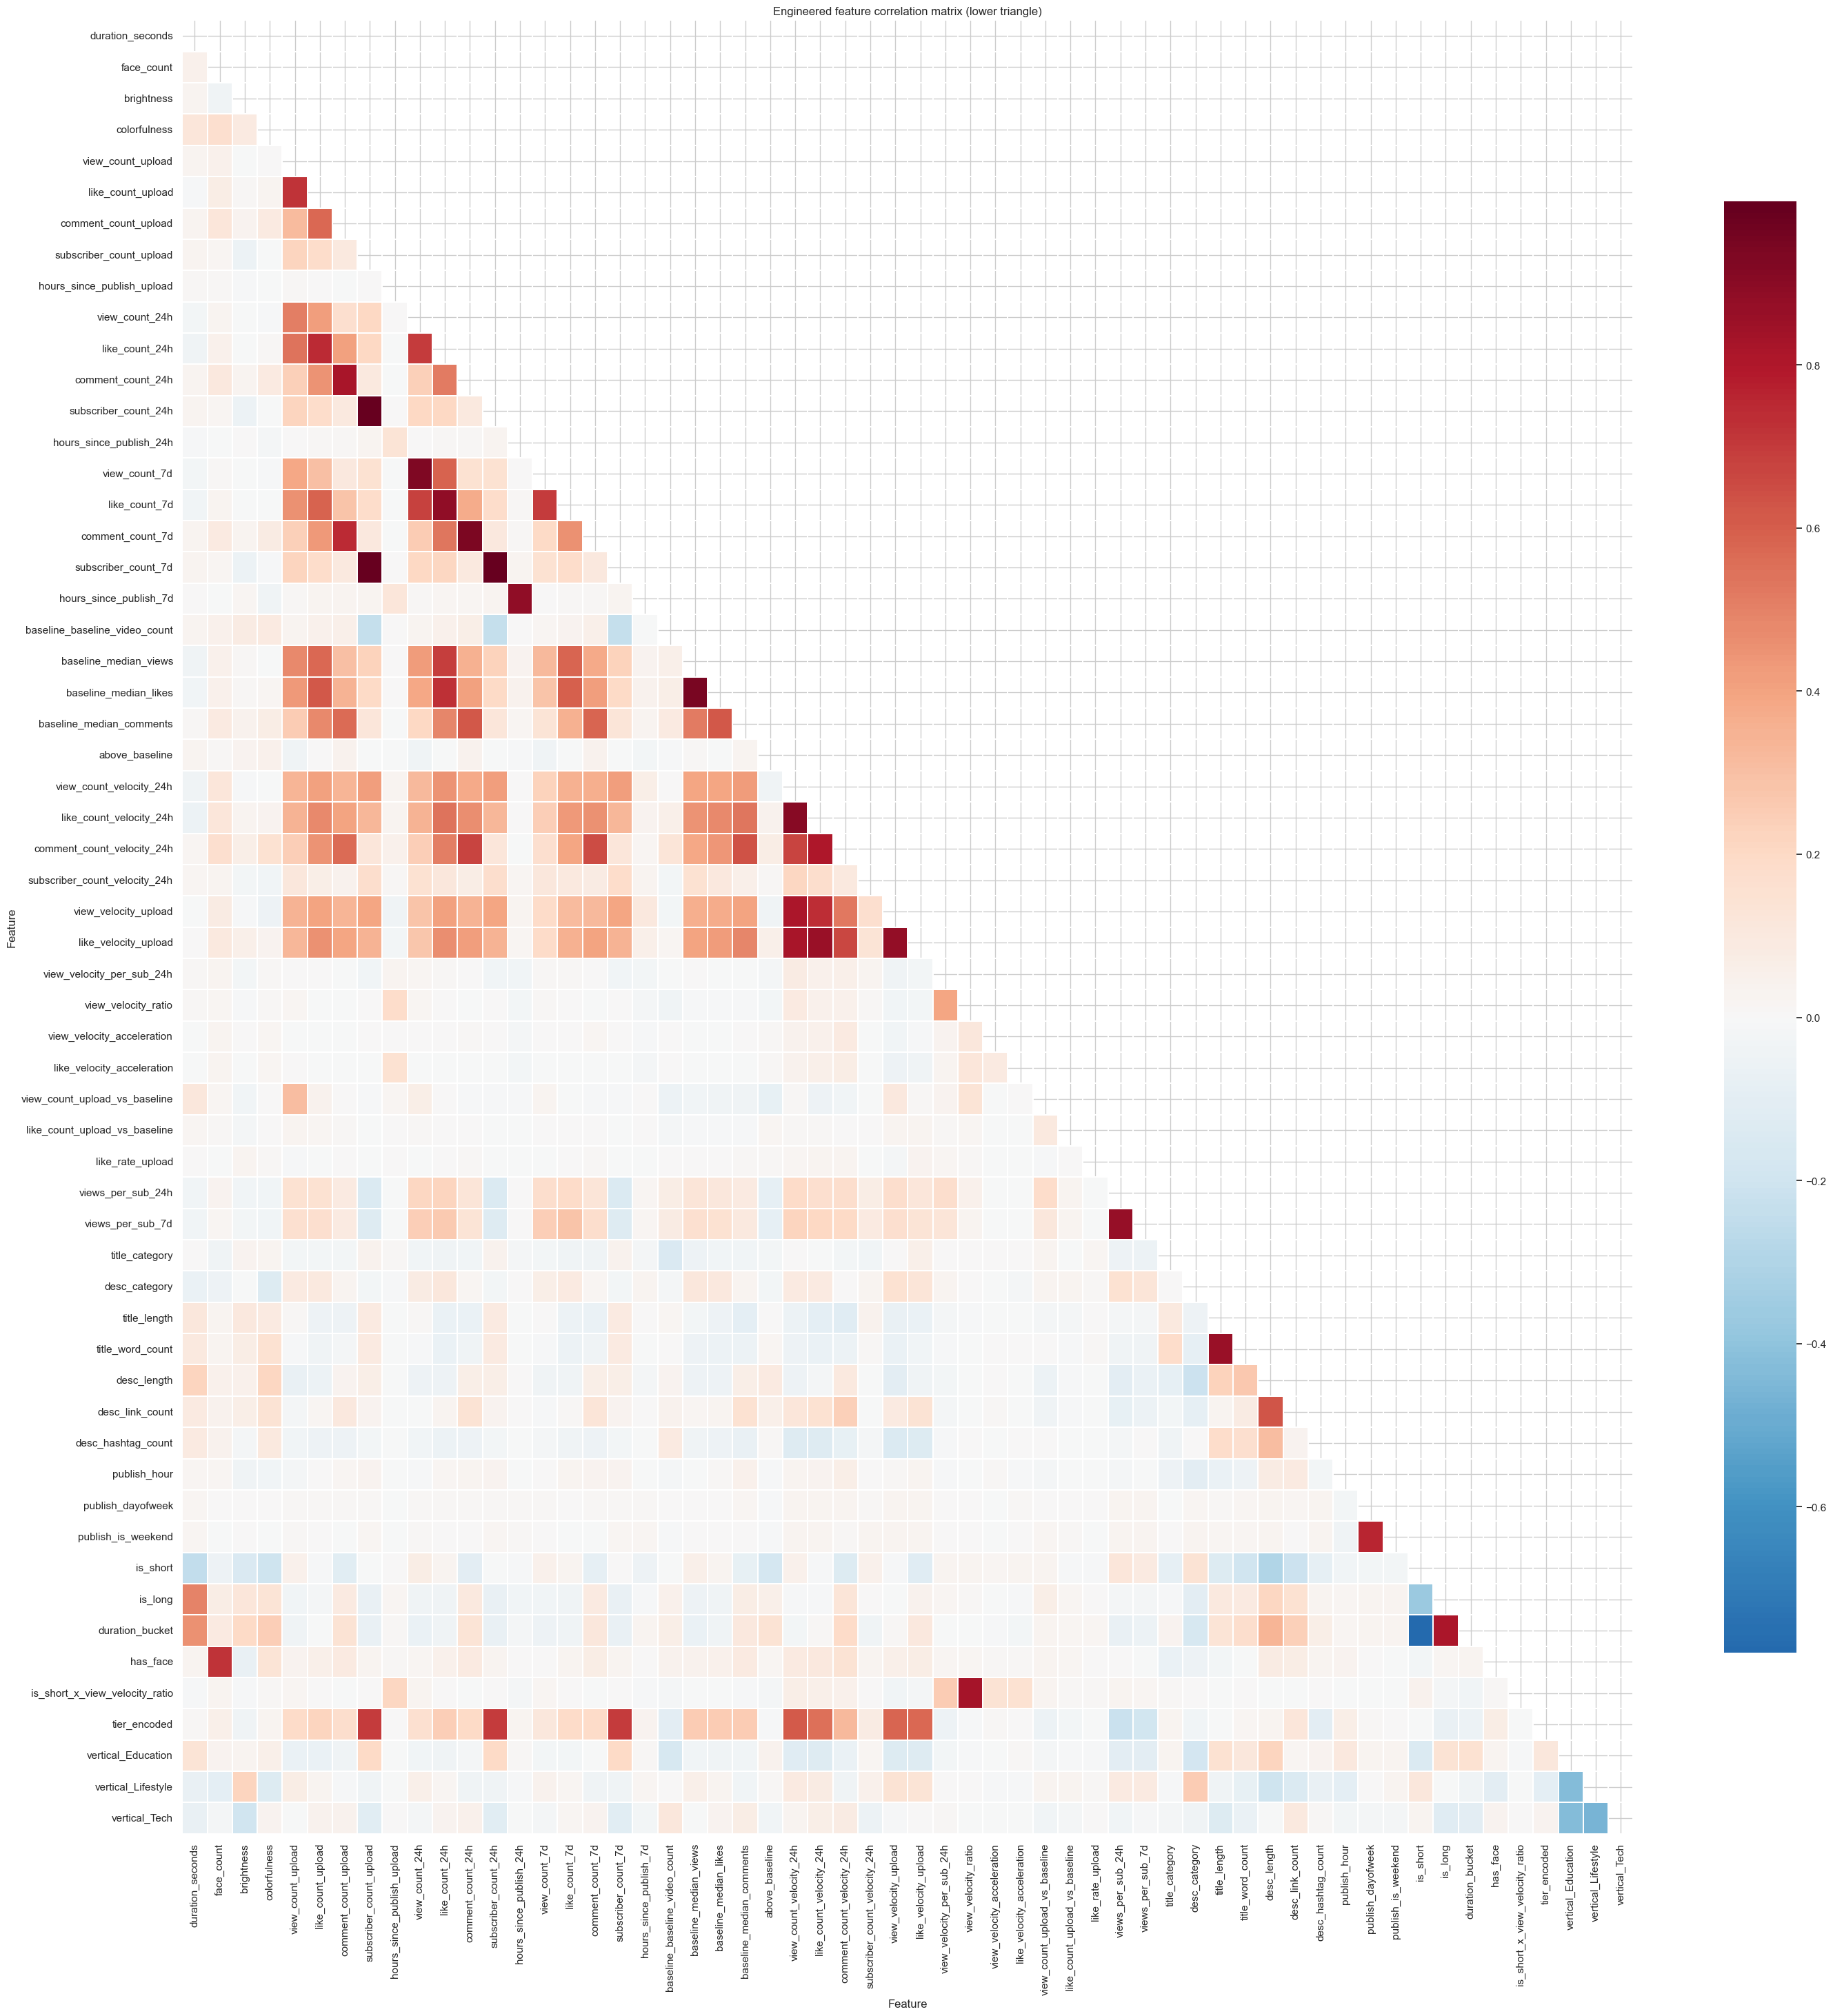

In [8]:
if config.is_skip_eda:
    print("skip_eda — skipping feature correlation heatmap.")
else:
    eda.set_active_df(run, run.df_engineered)
    eda.set_fig_size(run, 14, 12)
    ax = eda.plot_feature_correlations(run)
    ax.set_title("Engineered feature correlation matrix (lower triangle)")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Feature")
    eda.save_fig(ax.figure, fig_path("07_feature_correlation_heatmap.png"))
    plt.show()

### Shorts vs. standard videos

`is_short` has been a top feature since early model generations: YouTube Shorts
exhibit fundamentally different engagement dynamics. This view compares an
engagement rate between Shorts and standard videos, split by vertical — a
motivation for the `is_short` interaction features.

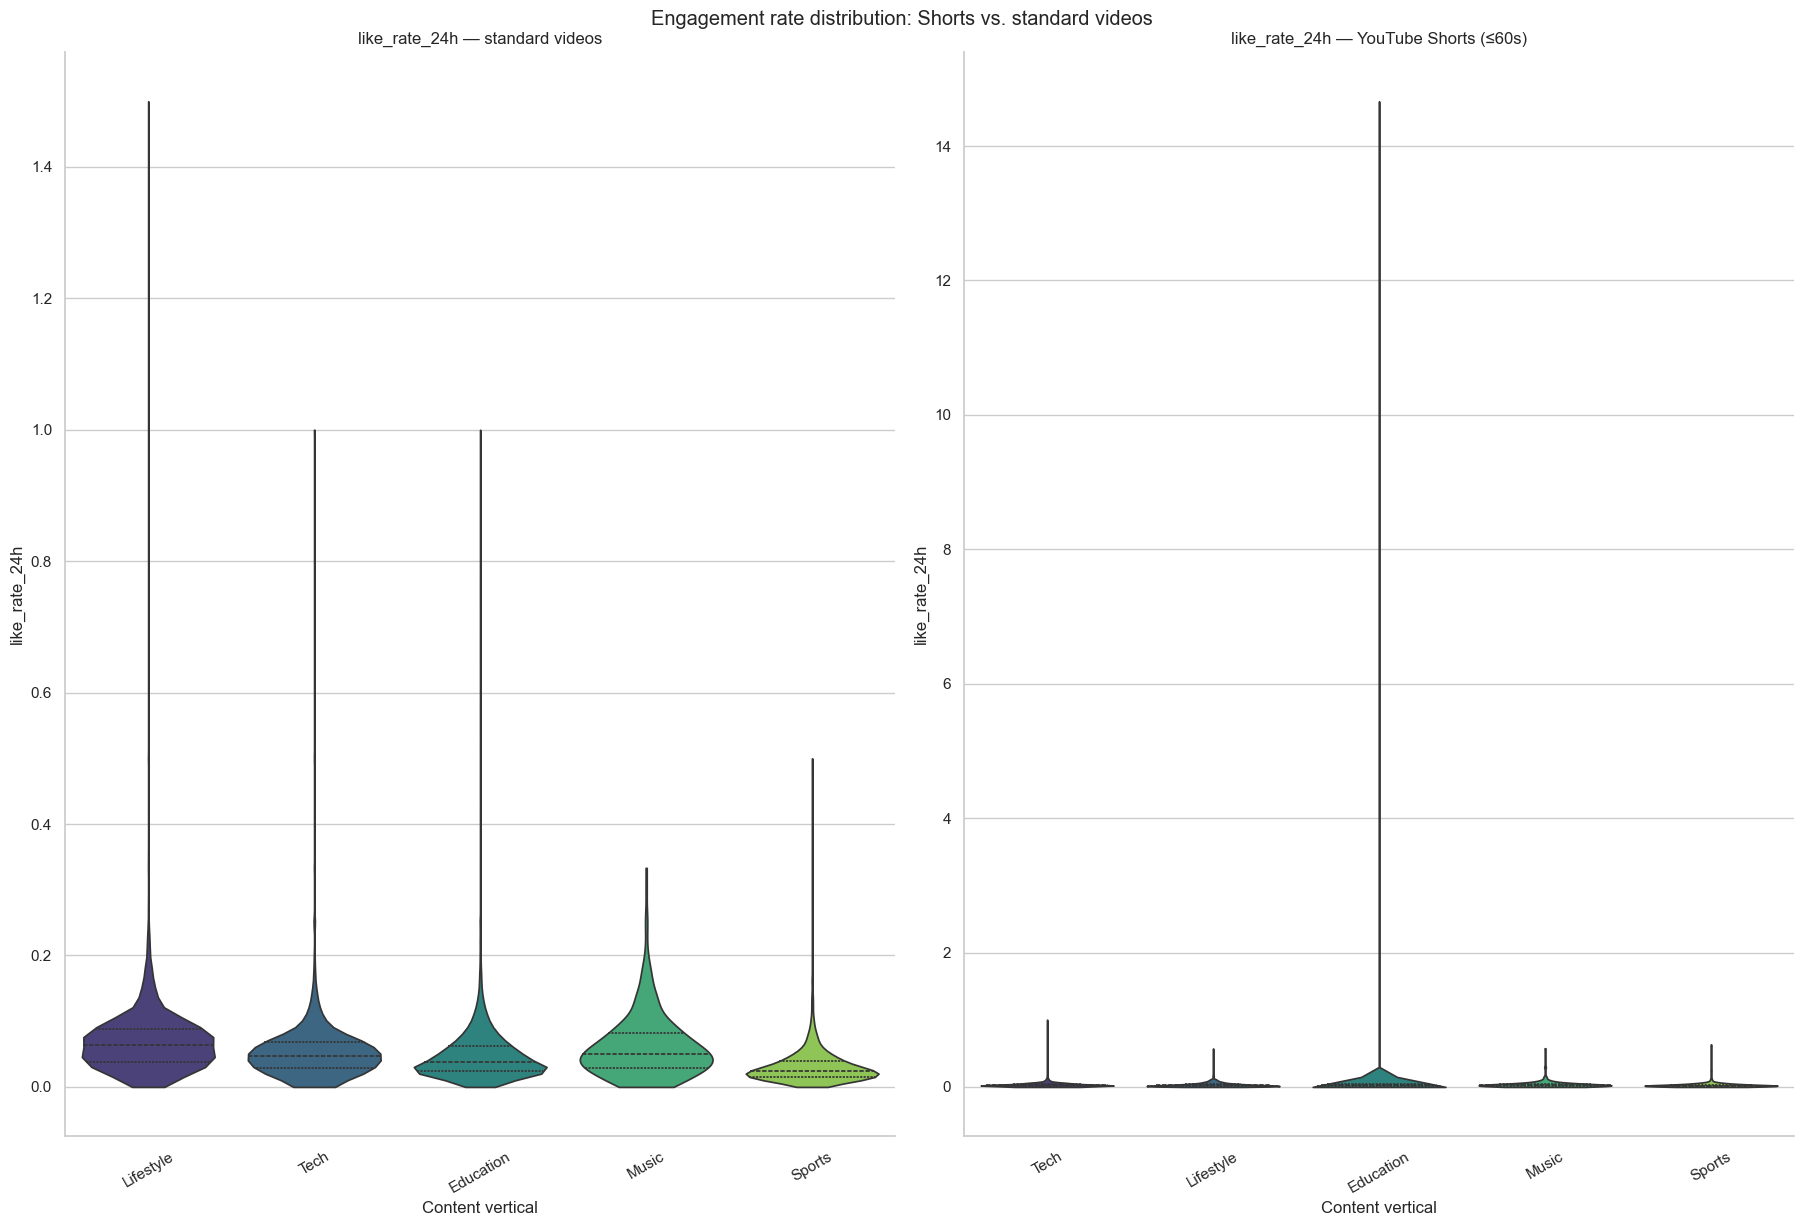

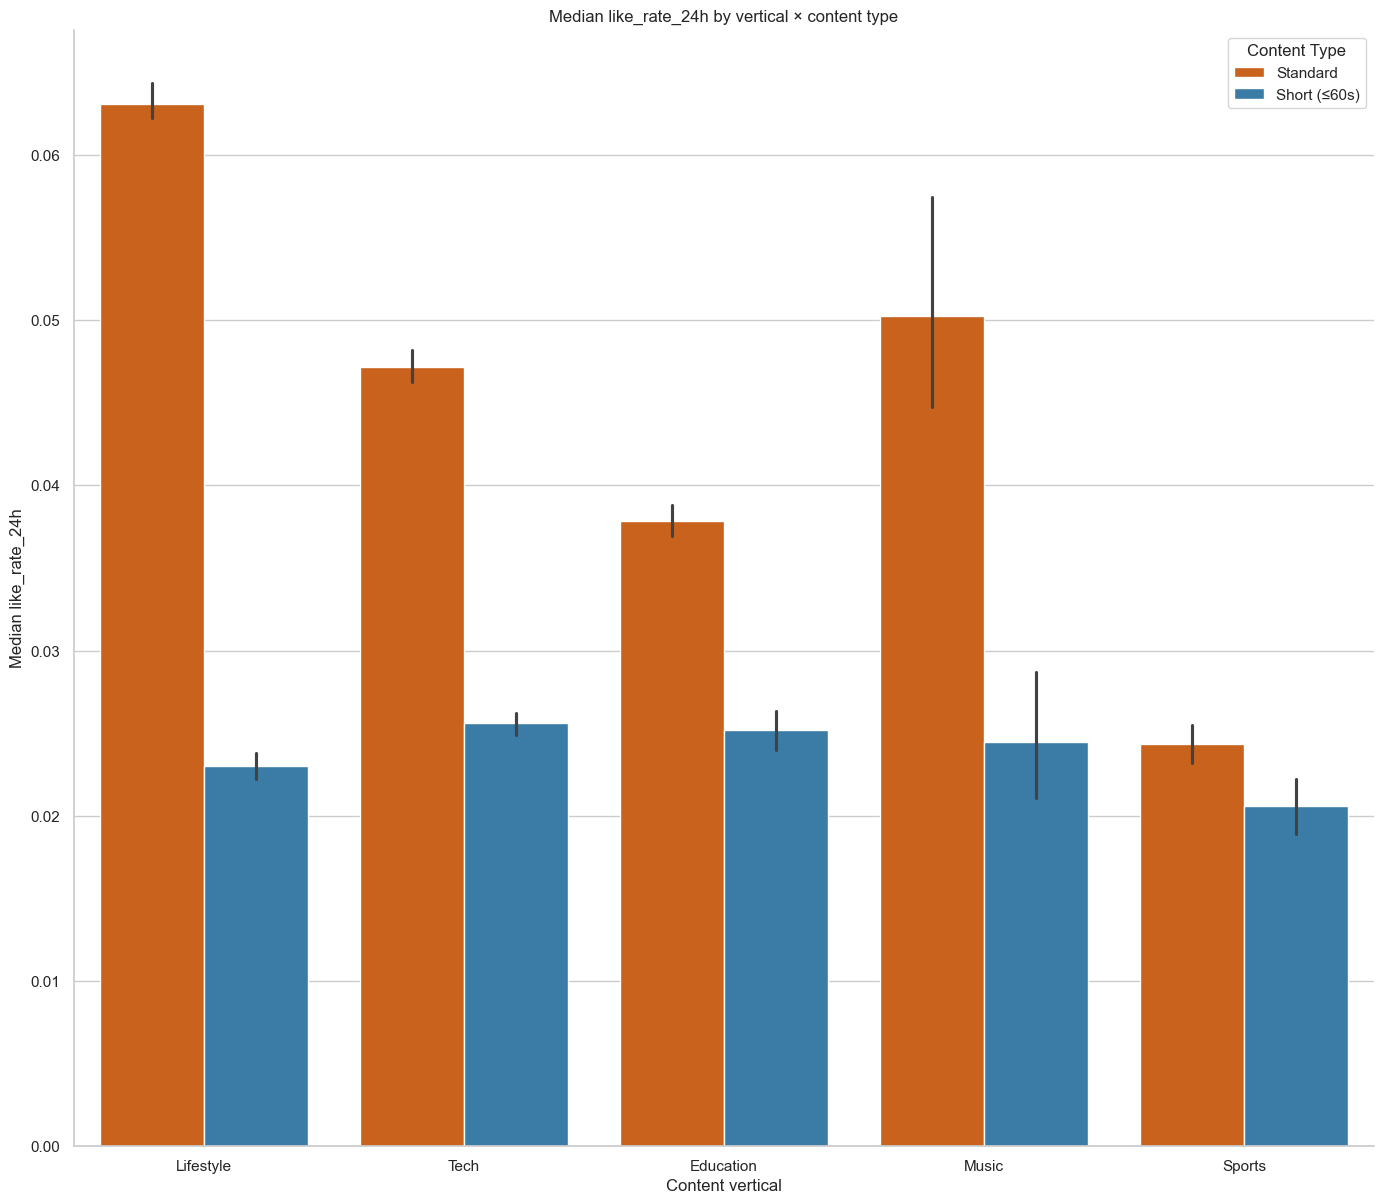

In [9]:
if config.is_skip_eda:
    print("skip_eda — skipping Shorts vs. standard comparison.")
else:
    eda.set_active_df(run, run.df_engineered)
    feature = "like_rate_24h"
    fig_violin, (ax_standard, ax_short), fig_bar, ax_bar = eda.plot_is_short_engagement(run, feature=feature)
    ax_standard.set_title(f"{feature} — standard videos")
    ax_standard.set_xlabel("Content vertical")
    ax_standard.set_ylabel(feature)
    ax_short.set_title(f"{feature} — YouTube Shorts (≤60s)")
    ax_short.set_xlabel("Content vertical")
    ax_short.set_ylabel(feature)
    fig_violin.suptitle("Engagement rate distribution: Shorts vs. standard videos", y=1.02)
    ax_bar.set_title(f"Median {feature} by vertical × content type")
    ax_bar.set_xlabel("Content vertical")
    ax_bar.set_ylabel(f"Median {feature}")
    eda.save_fig(fig_violin, fig_path("08_shorts_engagement_violin.png"))
    eda.save_fig(fig_bar, fig_path("08_shorts_engagement_bar.png"))
    plt.show()

## Findings — engineered data

- Feature engineering converts skewed raw counts into more symmetric,
  channel-relative signals — visibly so in the distribution comparison.
- The leakage check shows that 7d-derived features do not have notably elevated |r|
  with the target (highest: `views_per_sub_7d` at |r| ≈ 0.09). They are still
  excluded from the model before training because they contain future information not
  available at prediction time — their low correlation is a consequence of the
  target's relative definition, not proof that they are safe to include.
- The strongest correlates are content-format and early-signal features (`is_short`,
  `duration_bucket`, 24h velocity/rate features), validating the feature engineering
  strategy.
- Class balance varies by vertical/tier in structured ways, validating the
  stratified split key.

**Next:** [03 · Model training + results](./03_model_training_results.ipynb).